In [ ]:
import pandas as pd

data = pd.read_parquet(

)

### DataBase로부터 Service를 이용

현재까지 지원되는 기능으로는

- `IndustryService`
- `FreightService`
- `PriceService`
- `MacroService`

가 있음.

In [1]:
import pandas as pd
import numpy as np
from sympy import false

from src.service.industry import IndustryService
from src.service.freight import FreightService
from src.service.market import PriceService
from src.service.macro import MacroService

freights = FreightService(db_path='../database/alternative_data.duckdb')
industry = IndustryService(db_path='../database/alternative_data.duckdb')
macro = MacroService(db_path = '../database/alternative_data.duckdb')
market = PriceService(db_path = '../database/alternative_data.duckdb')

In [6]:
freights.get_series(
    symbols = freights.available_symbols(),
    index_set = 'release_date',
    full_data = False
)

symbol,BAI00,BAI20,BAI30,BAI40,BAI50,BAI60,BAI80,BCI,BCTI,BDI,...,USRT,WCI,WCILASH,WCINYRD,WCIRDNY,WCIRDSH,WCISHGN,WCISHLA,WCISHNY,WCISHRD
release_date,,,,,,,,,,,,,,,,,,,,,
1990-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1602.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1609.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1619.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1644.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13,2486.0,1165.0,4280.0,1164.0,1134.0,311.0,5533.0,4702.0,1128.0,2960.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4751.0,1176.0,2980.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4594.0,1190.0,2929.0,...,503525.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='release_date'>

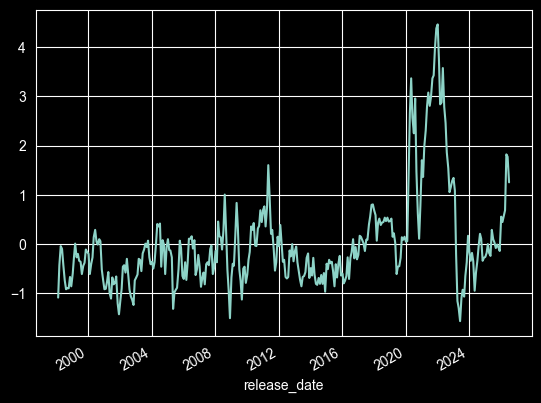

In [7]:
freights.get_series(
    symbols = 'GSCPI',
    index_set = 'release_date',
    full_data = False
).plot()

<Axes: xlabel='base_date'>

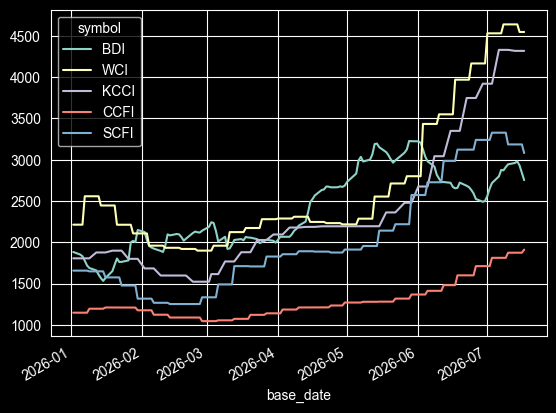

In [8]:
freights.get_series(
    symbols = [
        'BDI','WCI','KCCI','CCFI','SCFI'
    ]
).ffill().loc['2026':].plot()

In [9]:
industry.get_series(
    symbols = ['DXDDR5M16G','DXDDR4M16G','DXDDR4M8G'],
    full_data = True
).xs('average', axis = 1, level = 1)

symbol,DXDDR4M16G,DXDDR4M8G,DXDDR5M16G
base_date_full,,,
2022-01-28 19:10:00+09:00,NaN,3.89,NaN
2022-02-07 19:10:00+09:00,NaN,3.89,NaN
2022-02-08 19:10:00+09:00,NaN,3.89,NaN
2022-02-09 19:10:00+09:00,NaN,3.89,NaN
2022-02-10 19:10:00+09:00,NaN,3.87,NaN
...,...,...,...
2026-07-16 15:40:00+09:00,80.125,39.90,49.333
2026-07-16 19:10:00+09:00,80.125,39.90,49.333
2026-07-17 12:00:00+09:00,80.200,40.50,49.733


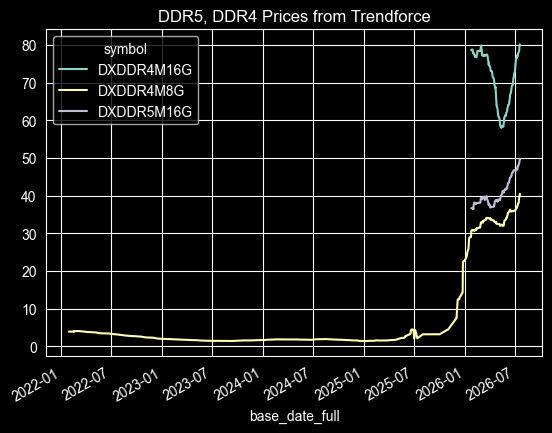

In [10]:
import matplotlib.pyplot as plt

industry.get_series(
    symbols = ['DXDDR5M16G','DXDDR4M16G','DXDDR4M8G'],
    full_data = True
).xs('average', axis = 1, level = 1).plot()
plt.title('DDR5, DDR4 Prices from Trendforce')
plt.show()

<Axes: xlabel='release_date_full'>

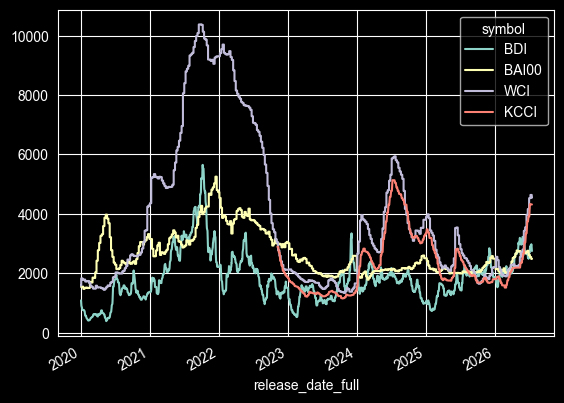

In [11]:
freights.get_series(symbols = ['BDI','BAI00','WCI','KCCI'], index_set = 'release_date', full_data = True).ffill().loc['2020':].plot()

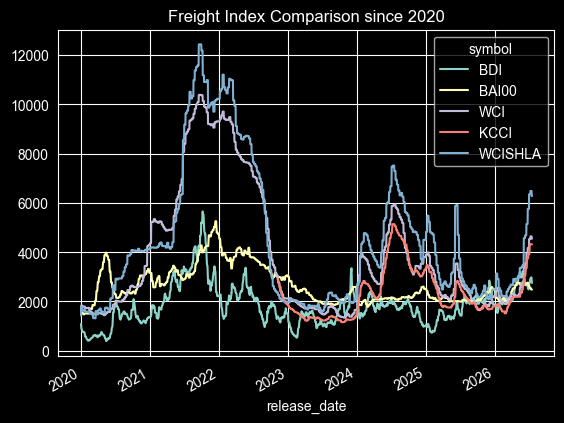

In [12]:
import matplotlib.pyplot as plt

freights.get_series(symbols = ['BDI','BAI00','WCI','KCCI','WCISHLA'], index_set = 'release_date').ffill().loc['2020':].plot()
plt.title('Freight Index Comparison since 2020')
plt.show()

In [14]:
industry = IndustryService(
    db_path = '../database/alternative_data.duckdb'
)

In [15]:
sam_ind = industry.get_series(
    symbols = ['DXI','CFMDRAM'],
    full_data = True
)

<Axes: xlabel='base_date_full'>

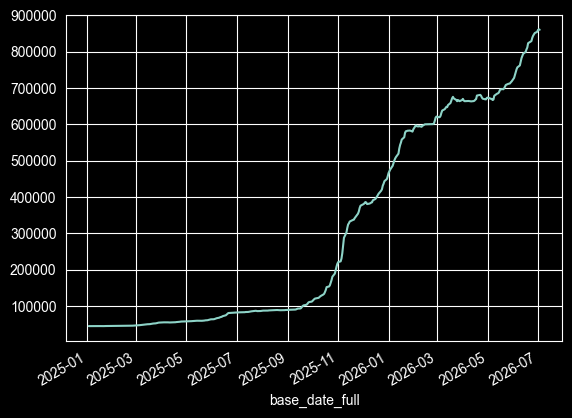

In [16]:
sam_ind['DXI'].dropna().loc['2025':].plot()

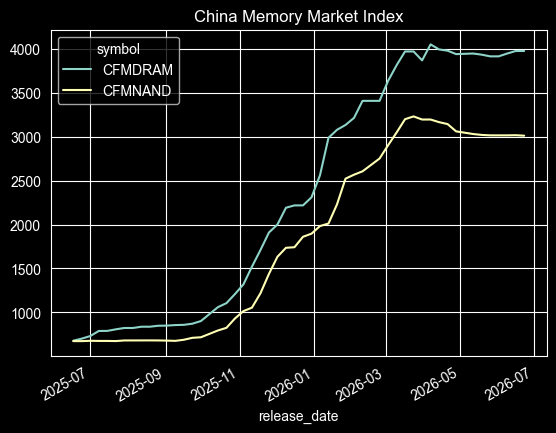

In [17]:
industry.get_series(
    symbols = ['CFMDRAM','CFMNAND'],
    index_set = 'release_date'
).plot()
plt.title('China Memory Market Index')
plt.show()

In [25]:
from src.service.macro import MacroService

macro = MacroService(db_path='../database/alternative_data.duckdb')

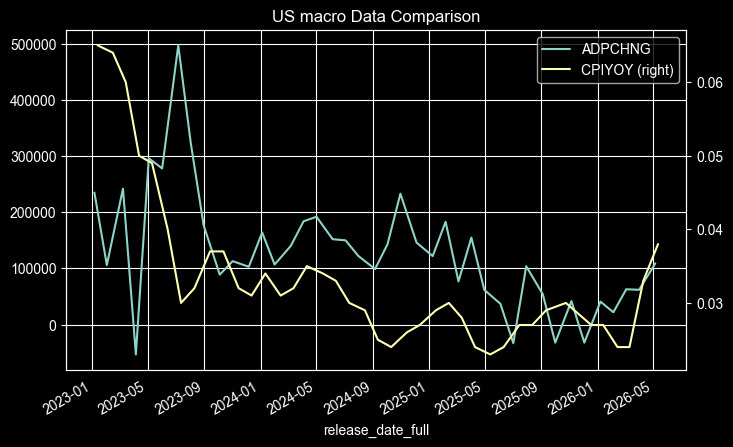

In [26]:
ax = macro.get_series(
    symbols=['ADPCHNG'],
    index_set='release_date',
    full_data=True,
    tz='utc-4',
).loc['2023':]['ADPCHNG'].plot(
    figsize=(8, 5),
    label='ADPCHNG'
)

ax2 = macro.get_series(
    symbols=['CPIYOY'],
    index_set='release_date',
    full_data=True,
    tz='utc-4',
).loc['2023':]['CPIYOY'].plot(
    ax=ax,
    secondary_y=True,
    label='CPIYOY'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.title(
    'US macro Data Comparison'
)
plt.show()

<Axes: >

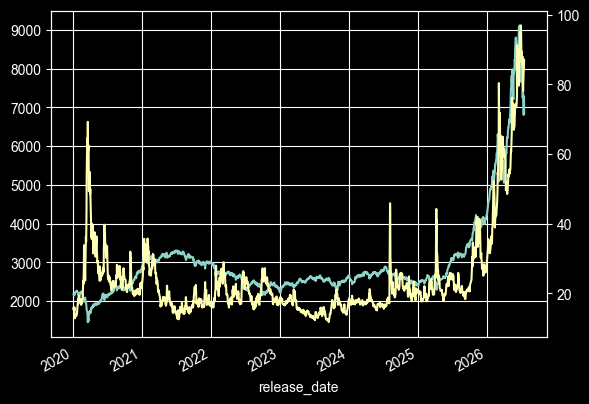

In [27]:
market.get_series(
    symbols = ['KOSPI','VKOSPI'],
    index_set = 'release_date',
    value_column = 'close'
)['KOSPI'].loc['2020':].plot()
market.get_series(
    symbols = ['KOSPI','VKOSPI'],
    index_set = 'release_date',
    value_column = 'close'
)['VKOSPI'].loc['2020':].plot(secondary_y = True)

In [28]:
selected_market_data = market.get_series(
    symbols = ['KOSPI','VKOSPI','KRX300'],
    index_set = 'release_date',
    multi_level_index = False
)#.loc['2020':]

In [29]:
selected_market_data['close']['VKOSPI'].dropna()

release_date
2013-02-04    15.76
2013-02-05    15.79
2013-02-06    15.11
2013-02-07    14.59
2013-02-08    14.25
              ...  
2026-07-10    78.15
2026-07-13    83.33
2026-07-14    83.97
2026-07-15    85.79
2026-07-16    87.14
Name: VKOSPI, Length: 3300, dtype: float64

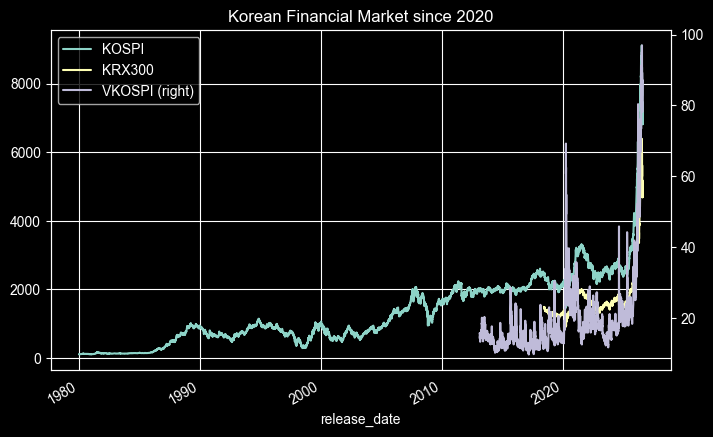

In [30]:
ax = selected_market_data['close']['KOSPI'].plot(
    figsize=(8, 5),
    label='KOSPI'
)

ax2 = selected_market_data['close']['KRX300'].plot(
    ax=ax,
    label='KRX300'
)

ax3 = selected_market_data['close']['VKOSPI'].plot(
    ax = ax,
    secondary_y = True,
    label = 'VKOSPI'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax.legend(
    lines1 + lines3,
    labels1 + labels3,
    loc='upper left'
)

plt.title(
    'Korean Financial Market since 2020'
)
plt.show()

In [24]:
selected_market_data = market.get_series(
    symbols = ['NI225','NKVI','VVIX'],
    index_set = 'release_date',
    multi_level_index = False
).loc['2020':]

In [25]:
selected_market_data

field                close                        high                \
symbol               NI225   NKVI   VVIX         NI225   NKVI   VVIX   
release_date                                                           
2020-01-02             NaN    NaN  89.67           NaN    NaN  93.65   
2020-01-03             NaN    NaN  93.79           NaN    NaN  99.92   
2020-01-06    23204.859375  16.87  92.66  23365.359375  16.87  96.41   
2020-01-07    23575.720703  15.11  91.07  23577.439453  15.88  93.44   
2020-01-08    23204.759766  17.25  90.21  23303.210938  19.19  91.57   
...                    ...    ...    ...           ...    ...    ...   
2026-07-01    70474.960938  33.78  89.04  71962.343750  39.52  89.87   
2026-07-02    68733.148438  24.74  88.80  70081.390625  40.42  91.37   
2026-07-03    69744.070312  34.11    NaN  69788.031250  39.51    NaN   
2026-07-06    69737.687500  37.36  87.09  70384.593750  38.32  91.71   
2026-07-07             NaN    NaN  89.49  69957.507812    NaN  90.45   

field                  low                        open                \
symbol               NI225   NKVI   VVIX         NI225   NKVI   VVIX   
release_date                                                           
2020-01-02             NaN    NaN  88.93           NaN    NaN  92.66   
2020-01-03             NaN    NaN  90.68           NaN    NaN  99.92   
2020-01-06    23148.529297  15.74  92.15  23319.759766  16.30  96.37   
2020-01-07    23299.919922  15.00  89.66  23320.119141  15.88  92.80   
2020-01-08    22951.179688  16.38  86.71  23217.490234  16.38  90.33   
...                    ...    ...    ...           ...    ...    ...   
2026-07-01    70126.140625  33.78  87.36  70774.281250  37.78  88.43   
2026-07-02    68676.257812  24.74  86.32  70039.890625  38.82  88.03   
2026-07-03    67609.492188  34.10    NaN  68676.062500  39.20    NaN   
2026-07-06    68904.406250  36.86  87.09  69973.343750  36.97  91.55   
2026-07-07    68003.921875    NaN  87.05  69460.078125    NaN  87.41   

field              volume            
symbol              NI225 NKVI VVIX  
release_date                         
2020-01-02            NaN  NaN  0.0  
2020-01-03            NaN  NaN  0.0  
2020-01-06     72800000.0  0.0  0.0  
2020-01-07     64300000.0  0.0  0.0  
2020-01-08     79400000.0  0.0  0.0  
...                   ...  ...  ...  
2026-07-01    163400000.0  0.0  0.0  
2026-07-02    169900000.0  0.0  0.0  
2026-07-03    159300000.0  0.0  NaN  
2026-07-06    135400000.0  0.0  0.0  
2026-07-07            0.0  NaN  0.0  

[1693 rows x 15 columns]

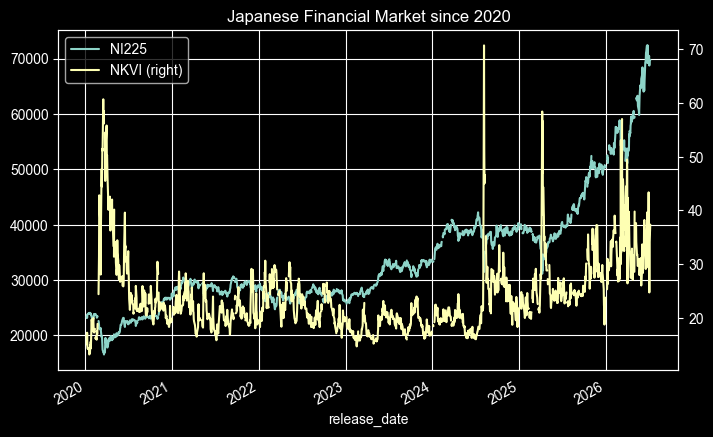

In [26]:
ax = selected_market_data['close']['NI225'].plot(
    figsize=(8, 5),
    label='NI225'
)

ax3 = selected_market_data['close']['NKVI'].plot(
    ax = ax,
    secondary_y = True,
    label = 'NKVI'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax.legend(
    lines1 + lines3,
    labels1 + labels3,
    loc='upper left'
)

plt.title(
    'Japanese Financial Market since 2020'
)
plt.show()

<Axes: >

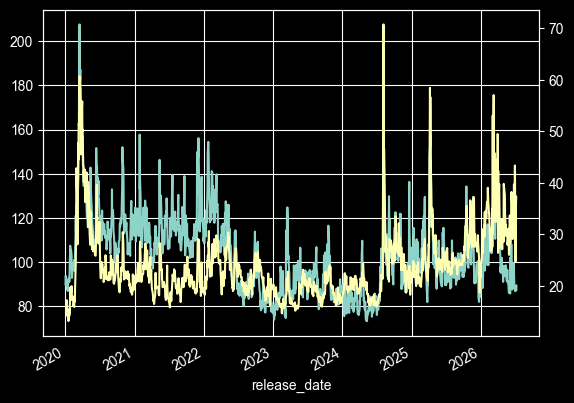

In [27]:
selected_market_data['close']['VVIX'].dropna().plot()
selected_market_data['close']['NKVI'].dropna().plot(secondary_y = True)

In [28]:
market.get_series(
    symbols = ['USDKRW','JPYKRW'],
    full_data = False
)

symbol     JPYKRW                               USDKRW                    \
field       close   high    low   open volume    close     high      low   
base_date                                                                  
1981-04-13    NaN    NaN    NaN    NaN    NaN   675.40   675.40   675.40   
1981-04-14    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-15    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-16    NaN    NaN    NaN    NaN    NaN   676.70   676.70   676.70   
1981-04-17    NaN    NaN    NaN    NaN    NaN   676.75   676.75   676.75   
...           ...    ...    ...    ...    ...      ...      ...      ...   
2026-07-01  9.522  9.564  9.495  9.495    0.0  1553.61  1558.98  1545.90   
2026-07-02  9.529  9.593  9.529  9.545    0.0  1538.00  1557.90  1537.28   
2026-07-03  9.465  9.570  9.465  9.530    0.0  1530.15  1548.28  1526.28   
2026-07-06  9.468  9.497  9.449  9.465    0.0  1530.45  1537.28  1527.38   
2026-07-07  9.334  9.427  9.334  9.427    0.0  1513.83  1531.78  1511.03   

symbol                      
field          open volume  
base_date                   
1981-04-13   675.40    0.0  
1981-04-14   676.70    0.0  
1981-04-15   676.70    0.0  
1981-04-16   676.70    0.0  
1981-04-17   676.75    0.0  
...             ...    ...  
2026-07-01  1546.61    0.0  
2026-07-02  1553.62    0.0  
2026-07-03  1537.99    0.0  
2026-07-06  1529.16    0.0  
2026-07-07  1531.17    0.0  

[11544 rows x 10 columns]

NameError: name 'fx' is not defined